In [1]:
import os, sys
from pathlib import Path

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))

import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pickle

from src.preprocess import preprocess_df
from src.network_connectivity import ConnectivityUnit
from src.kalman_network_tools import graphs_2_risk_scores
from src.network_plotting import risks_over_time_2d, risks_over_time_3d

In [13]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv' 
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')

df = preprocess_df(df_cic, date_col=' Timestamp')
print(df.shape)
df = df.iloc[:303_500, :].copy()
#df = df.iloc[300_000:303_500, :].copy()

(445645, 85)


In [14]:
df

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
133037,192.168.10.25-54.192.37.17-54988-443-6,54.192.37.17,443,192.168.10.25,54988,6,2017-04-07 01:00:00,54,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
394262,192.168.10.9-87.250.250.119-5303-443-6,87.250.250.119,443,192.168.10.9,5303,6,2017-04-07 01:00:00,101114,2,1,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
132995,192.168.10.25-52.84.145.136-54978-443-6,192.168.10.25,54978,52.84.145.136,443,6,2017-04-07 01:00:00,169399,22,30,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
132994,192.168.10.9-87.250.250.119-5260-443-6,192.168.10.9,5260,87.250.250.119,443,6,2017-04-07 01:00:00,148,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
138980,192.168.10.12-199.182.221.110-123-123-17,192.168.10.12,123,199.182.221.110,123,17,2017-04-07 01:00:00,71771,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64841,192.168.10.1-192.168.10.3-53-61351-17,192.168.10.3,61351,192.168.10.1,53,17,2017-04-07 09:54:00,103492616,2,2,...,32,30683.0,0.0,30683.0,30683.0,103000000.0,0.0,103000000.0,103000000.0,BENIGN
55629,192.168.10.1-192.168.10.3-53-61805-17,192.168.10.3,61805,192.168.10.1,53,17,2017-04-07 09:54:00,30915,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
46547,192.168.10.1-192.168.10.3-53-62463-17,192.168.10.3,62463,192.168.10.1,53,17,2017-04-07 09:54:00,31157,1,1,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
46516,192.168.10.1-192.168.10.3-53-62438-17,192.168.10.3,62438,192.168.10.1,53,17,2017-04-07 09:54:00,163332,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [5]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
    entity_names = pickle.load(handle)
len(entity_names)

13

Conditioning number:  3.3900564024158837 
Determinant of F^T*F:  0.9848011774715898


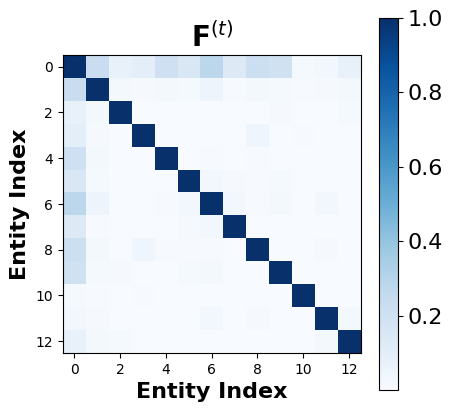

In [6]:
cu = ConnectivityUnit()
cu.read_flows(df, conn_param='NPR', entity_names=entity_names,
             window_type= 'time', sync_window_size= 1.2, time_scale= 'sec')

cu.fit_graph_model(method = 'cov') # cov
cu.plot_f(labels=True)
mthd_name = 'Corr. Coeff.'

In [7]:
import importlib
import src.kalman_network_tools

importlib.reload(src.kalman_network_tools)
from src.kalman_network_tools import *

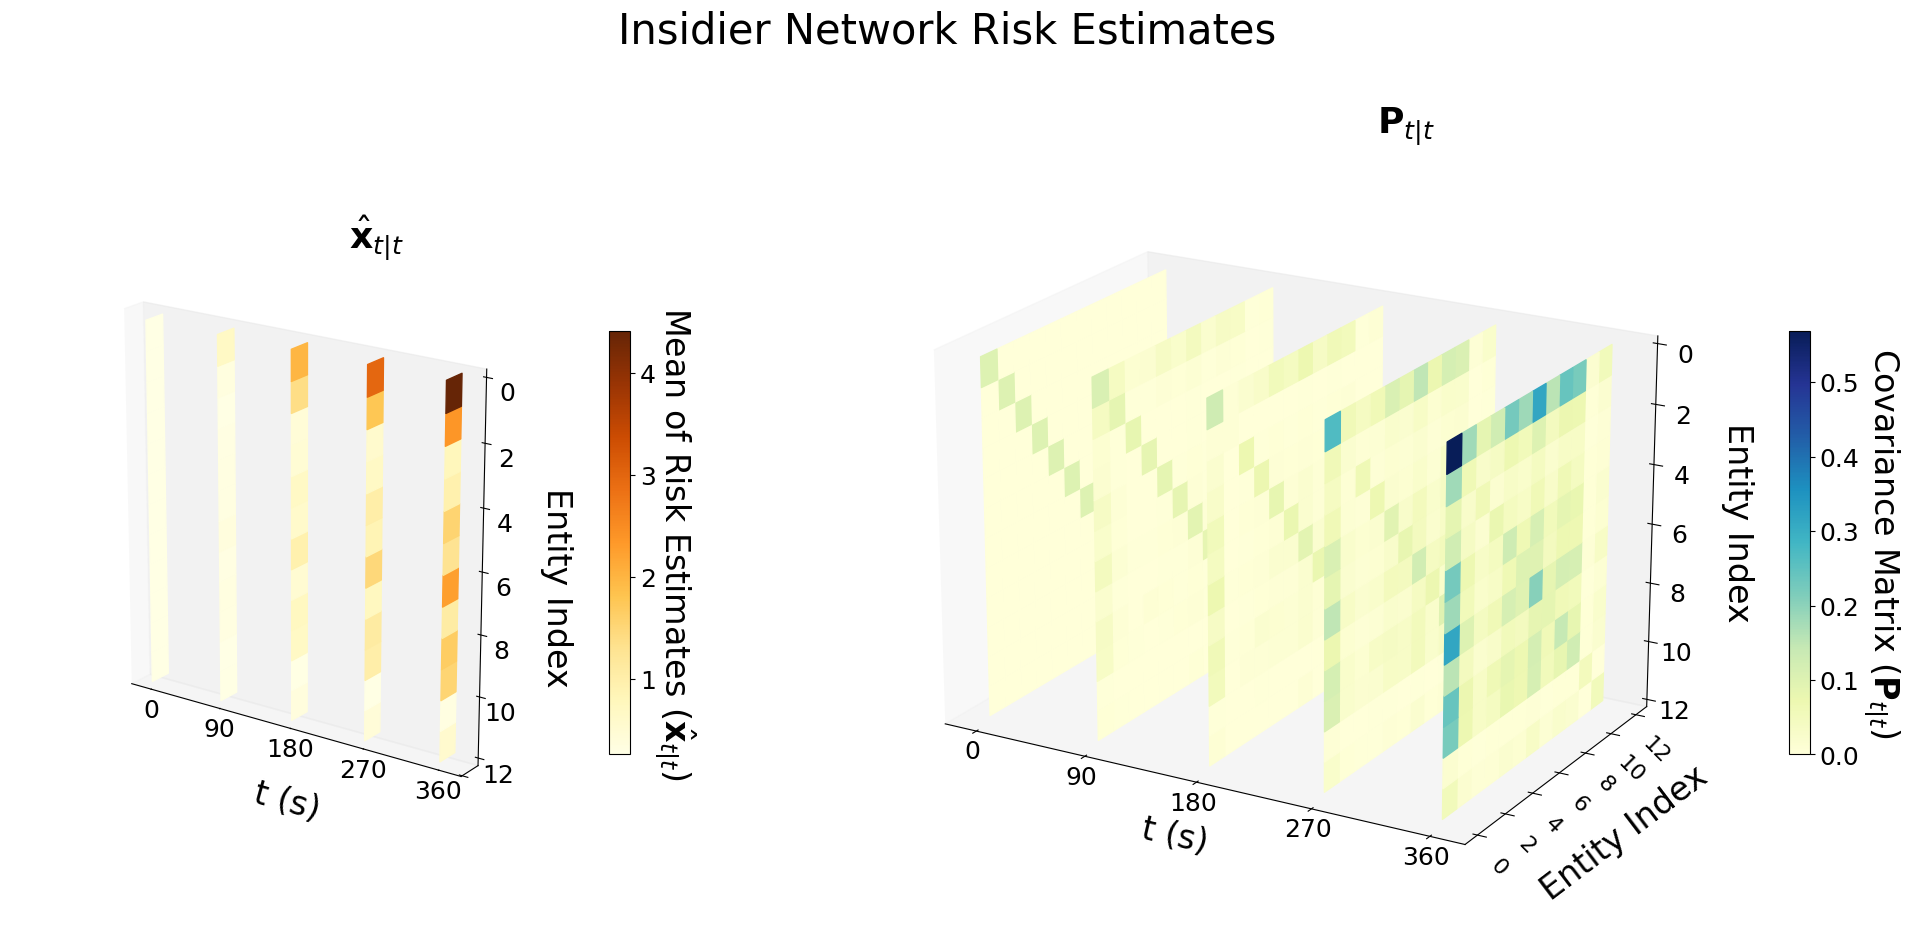

In [17]:
nn = 4 # 4
n_nodes = len(entity_names)
all_graphs = [cu.F for i in range(nn)]
all_measurements = [None for _ in range(nn)]
all_measurements[1] = np.array([1.6])
all_mat_h = [None for _ in range(nn)]
mat_h = np.zeros((1, len(entity_names)))
mat_h[0, 1] = 1
all_mat_h[1] = mat_h
all_mat_q = [np.eye(n_nodes, n_nodes) / 10 ** 3 for _ in range(nn)]
all_mat_r = [np.eye(1, 1) / 10 ** 2 for _ in range(nn)]

x_list, P_list = graphs_2_risk_scores(all_graphs, all_measurements=all_measurements, all_mat_h=all_mat_h, all_mat_q=all_mat_q,
                                      all_mat_r=all_mat_r, k_steps=1, relief_factor=0.09, sequential=True, normalize=False,
                                      return_cov=True)
fig = risks_over_time_3d(x_list, P_list, t_graph=90, title='Insidier Network Risk Estimates', save_name='saves/risk_ests_3d_v3.jpg')

In [18]:
all_measurements, all_mat_h

([None, array([1.6]), None, None],
 [None,
  array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
  None,
  None])

In [53]:
import importlib
import src.network_plotting

importlib.reload(src.network_plotting)
from src.network_plotting import *

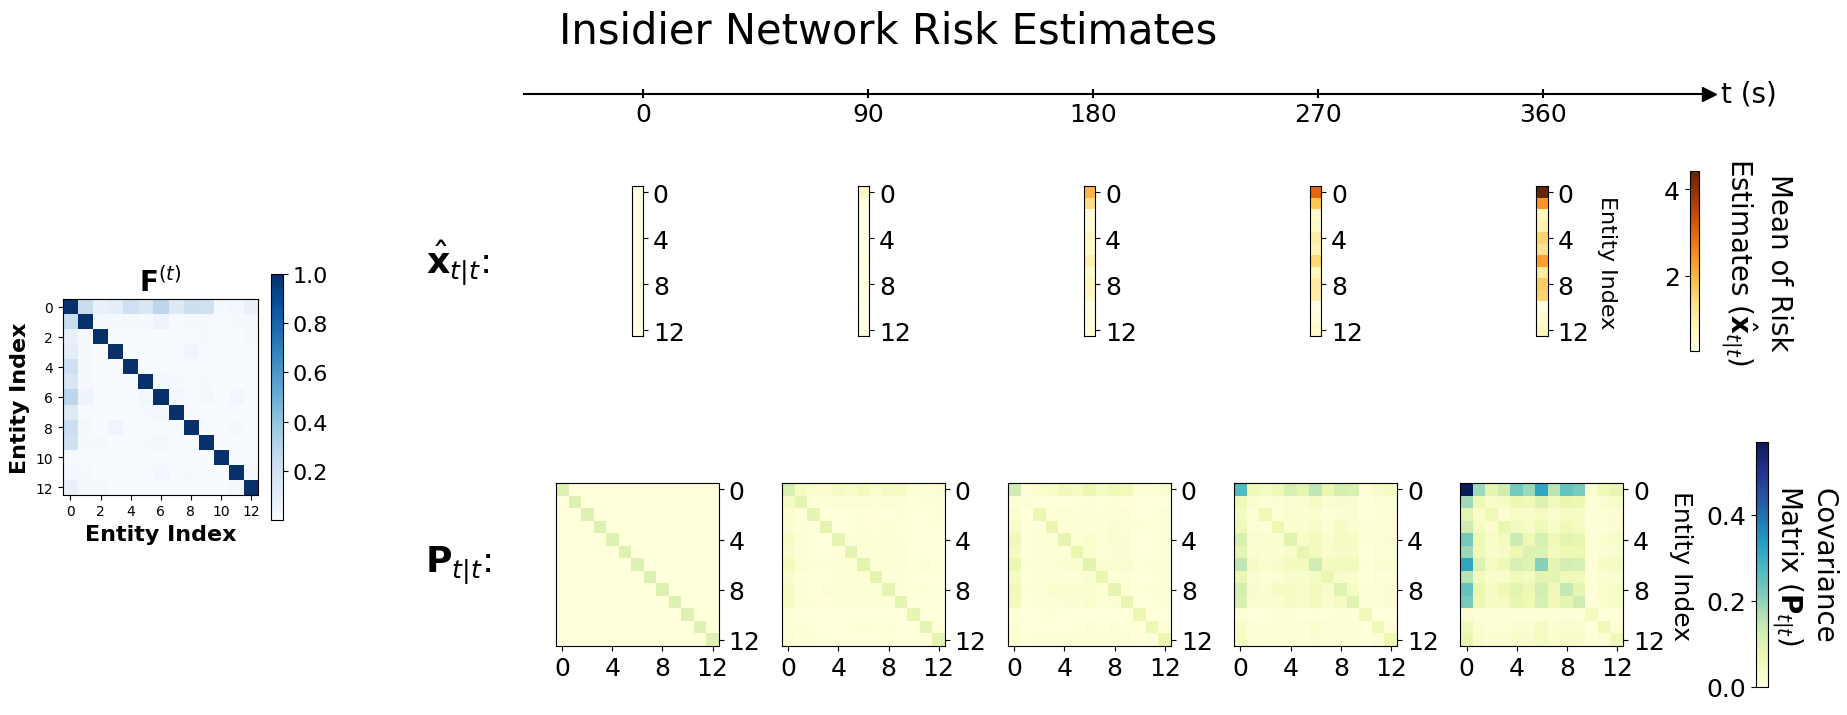

In [54]:
fig = risks_over_time_2d(x_list, P_list, cu.F, t_graph=90, title='Insidier Network Risk Estimates',
                         save_name='saves/risk_ests_2d.jpg')

In [16]:
{i: name for i, name in enumerate(entity_names)}

{0: '192.168.10.3',
 1: '192.168.10.50',
 2: '192.168.10.51',
 3: '192.168.10.19',
 4: '192.168.10.17',
 5: '192.168.10.16',
 6: '192.168.10.12',
 7: '192.168.10.9',
 8: '192.168.10.5',
 9: '192.168.10.8',
 10: '192.168.10.14',
 11: '192.168.10.15',
 12: '192.168.10.25'}

In [ ]:
x_list

# Real-Time Example

In [ ]:
import importlib
import src.real_time_model

importlib.reload(src.real_time_model)
from src.real_time_model import *

In [ ]:
import importlib
import src.kalman_network_tools

importlib.reload(src.kalman_network_tools)
from src.kalman_network_tools import *

In [ ]:
unit = NetworkUnit(entity_names)
x, p = unit.update_new_tick(df.iloc[:100] )

In [ ]:
x